# 02 — Prophet Model (Ish kunlari, 7 kun forecast)

**Yondashuv:**
- `freq='B'` (faqat ish kunlari)
- 7 ish kuni forecast (treasury haftalik rejalashtiradi)
- Outlier removal
- Hyperparameter tuning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from itertools import product
from time import time
import warnings
warnings.filterwarnings('ignore')

import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

plt.rcParams['figure.figsize'] = (14, 5)

Importing plotly failed. Interactive plots will not work.


In [2]:
data = pd.read_csv('../data/synthetic_data.csv', parse_dates=['date'])
branches_df = pd.read_csv('../data/branches.csv')
print(f'{len(data):,} qator, {data["branch_id"].nunique()} filial')
print(f'Davr: {data["date"].min().date()} -> {data["date"].max().date()}')

10,200 qator, 20 filial
Davr: 2024-04-25 -> 2026-04-24


In [3]:
TEST_DAYS = 7    # 1 ish haftasi (treasury haftalik rejalashtiradi)
all_dates = sorted(data['date'].unique())
split_date_pd = pd.to_datetime(all_dates[-TEST_DAYS - 1])
print(f'Split: {split_date_pd.date()}')
print(f'Test:  oxirgi {TEST_DAYS} ish kuni')

Split: 2026-04-15
Test:  oxirgi 7 ish kuni


In [4]:
def remove_outliers(df, col='y', k=2.5):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    df = df.copy()
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    df.loc[(df[col] < lower) | (df[col] > upper), col] = np.nan
    return df, n_outliers


def fit_prophet(train_df, params):
    m = Prophet(
        weekly_seasonality=False,
        yearly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=params['cps'],
        seasonality_prior_scale=params['sps'],
    )
    # Monthly seasonality OLIB TASHLANDI - u noto'g'ri o'rganadi
    # O'rniga payday-ni regressor sifatida beramiz
    m.add_regressor('is_payday')
    m.fit(train_df)
    return m


def predict_business(model, last_date, periods):
    future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=periods)
    history_dates = pd.bdate_range(end=last_date, periods=500)
    all_dates = pd.DatetimeIndex(list(history_dates) + list(future_dates)).drop_duplicates().sort_values()
    future = pd.DataFrame({'ds': all_dates})
    future['is_payday'] = future['ds'].dt.day.isin(list(range(1, 6)) + list(range(25, 31))).astype(int)
    return model.predict(future)

def evaluate_model(test_df, forecast_df, split_date_pd):
    test_fcst = forecast_df[forecast_df['ds'] > split_date_pd][['ds', 'yhat']]
    merged = test_df.merge(test_fcst, on='ds')
    if len(merged) == 0:
        return np.nan, np.nan, merged
    mape = mean_absolute_percentage_error(merged['y'], merged['yhat']) * 100
    rmse = np.sqrt(mean_squared_error(merged['y'], merged['yhat']))
    return mape, rmse, merged

## Hyperparameter tuning

In [5]:
branch1 = data[data['branch_id'] == 1]
train1_raw = branch1[branch1['date'] <= split_date_pd][['date', 'balance', 'is_payday']].rename(columns={'date': 'ds', 'balance': 'y'})
test1 = branch1[branch1['date'] > split_date_pd][['date', 'balance', 'is_payday']].rename(columns={'date': 'ds', 'balance': 'y'})
train1, _ = remove_outliers(train1_raw)

param_grid = {
    'cps': [0.01, 0.05, 0.1, 0.2],
    'sps': [5.0, 10.0, 15.0],
}

results = []
t0 = time()
for cps, sps in product(param_grid['cps'], param_grid['sps']):
    m = fit_prophet(train1, {'cps': cps, 'sps': sps})
    fcst = predict_business(m, train1['ds'].max(), TEST_DAYS + 5)
    mape, _, _ = evaluate_model(test1, fcst, split_date_pd)
    results.append({'cps': cps, 'sps': sps, 'mape': mape})

results_df = pd.DataFrame(results).sort_values('mape')
best = results_df.iloc[0]
print(results_df.to_string(index=False))
print(f'\nEng yaxshi: cps={best["cps"]}, sps={best["sps"]}, MAPE={best["mape"]:.2f}%')
print(f'Vaqt: {time() - t0:.1f} sek')

16:56:18 - cmdstanpy - INFO - Chain [1] start processing
16:56:18 - cmdstanpy - INFO - Chain [1] done processing
16:56:18 - cmdstanpy - INFO - Chain [1] start processing
16:56:18 - cmdstanpy - INFO - Chain [1] done processing
16:56:18 - cmdstanpy - INFO - Chain [1] start processing
16:56:18 - cmdstanpy - INFO - Chain [1] done processing
16:56:18 - cmdstanpy - INFO - Chain [1] start processing
16:56:18 - cmdstanpy - INFO - Chain [1] done processing
16:56:18 - cmdstanpy - INFO - Chain [1] start processing
16:56:18 - cmdstanpy - INFO - Chain [1] done processing
16:56:18 - cmdstanpy - INFO - Chain [1] start processing
16:56:18 - cmdstanpy - INFO - Chain [1] done processing
16:56:18 - cmdstanpy - INFO - Chain [1] start processing
16:56:18 - cmdstanpy - INFO - Chain [1] done processing
16:56:18 - cmdstanpy - INFO - Chain [1] start processing
16:56:18 - cmdstanpy - INFO - Chain [1] done processing
16:56:18 - cmdstanpy - INFO - Chain [1] start processing
16:56:18 - cmdstanpy - INFO - Chain [1]

 cps  sps     mape
0.20 15.0 7.107252
0.20  5.0 7.125044
0.20 10.0 7.144757
0.10 10.0 7.215374
0.10  5.0 7.247344
0.10 15.0 7.266925
0.01  5.0 7.409602
0.01 10.0 7.493663
0.01 15.0 7.495955
0.05 15.0 7.562287
0.05  5.0 7.601035
0.05 10.0 7.614454

Eng yaxshi: cps=0.2, sps=15.0, MAPE=7.11%
Vaqt: 0.9 sek


## Barcha filiallar

In [6]:
best_params = {'cps': best['cps'], 'sps': best['sps']}

models = {}
metrics = []
predictions = {}

t0 = time()
for bid in branches_df['branch_id']:
    branch_data = data[data['branch_id'] == bid]
    train_raw = branch_data[branch_data['date'] <= split_date_pd][['date', 'balance', 'is_payday']].rename(
        columns={'date': 'ds', 'balance': 'y'})
    test = branch_data[branch_data['date'] > split_date_pd][['date', 'balance', 'is_payday']].rename(
        columns={'date': 'ds', 'balance': 'y'})
    train, n_out = remove_outliers(train_raw)
    
    m = fit_prophet(train, best_params)
    fcst = predict_business(m, train['ds'].max(), TEST_DAYS + 5)
    mape, rmse, merged = evaluate_model(test, fcst, split_date_pd)
    
    models[bid] = m
    metrics.append({'branch_id': bid, 'mape': mape, 'rmse_mln': rmse / 1e6, 'outliers': n_out})
    predictions[bid] = merged

metrics_df = pd.DataFrame(metrics)
print(f'Vaqt: {time() - t0:.1f} sek\n')
print(metrics_df.to_string(index=False))
print(f"\nO'rtacha MAPE: {metrics_df['mape'].mean():.2f}%")
print(f"10% dan past:  {(metrics_df['mape'] < 10).sum()}/{len(metrics_df)}")

16:56:19 - cmdstanpy - INFO - Chain [1] start processing
16:56:19 - cmdstanpy - INFO - Chain [1] done processing
16:56:19 - cmdstanpy - INFO - Chain [1] start processing
16:56:19 - cmdstanpy - INFO - Chain [1] done processing
16:56:19 - cmdstanpy - INFO - Chain [1] start processing
16:56:19 - cmdstanpy - INFO - Chain [1] done processing
16:56:19 - cmdstanpy - INFO - Chain [1] start processing
16:56:19 - cmdstanpy - INFO - Chain [1] done processing
16:56:19 - cmdstanpy - INFO - Chain [1] start processing
16:56:19 - cmdstanpy - INFO - Chain [1] done processing
16:56:19 - cmdstanpy - INFO - Chain [1] start processing
16:56:19 - cmdstanpy - INFO - Chain [1] done processing
16:56:19 - cmdstanpy - INFO - Chain [1] start processing
16:56:19 - cmdstanpy - INFO - Chain [1] done processing
16:56:19 - cmdstanpy - INFO - Chain [1] start processing
16:56:19 - cmdstanpy - INFO - Chain [1] done processing
16:56:19 - cmdstanpy - INFO - Chain [1] start processing
16:56:19 - cmdstanpy - INFO - Chain [1]

Vaqt: 1.6 sek

 branch_id      mape  rmse_mln  outliers
         1  7.107252 66.607409         1
         2  5.497876 29.560580         0
         3  8.689384 40.621924         0
         4 11.006670 53.604263         1
         5  5.468025 19.462641         1
         6  7.320521 18.347338         0
         7  3.889304 34.336208         0
         8 12.641878 35.887532         0
         9  6.804524 29.518067         1
        10  8.004106 16.624306         2
        11  6.162302 30.516212         0
        12  8.531478 37.355659         1
        13  8.156041 33.521661         0
        14  5.422095 16.482764         2
        15  3.767305 15.349793         1
        16 13.844029 34.810515         0
        17  7.836548 20.124837         1
        18  6.355003 21.365028         0
        19 10.582758 21.948734         2
        20 10.526866 22.076060         0

O'rtacha MAPE: 7.88%
10% dan past:  15/20


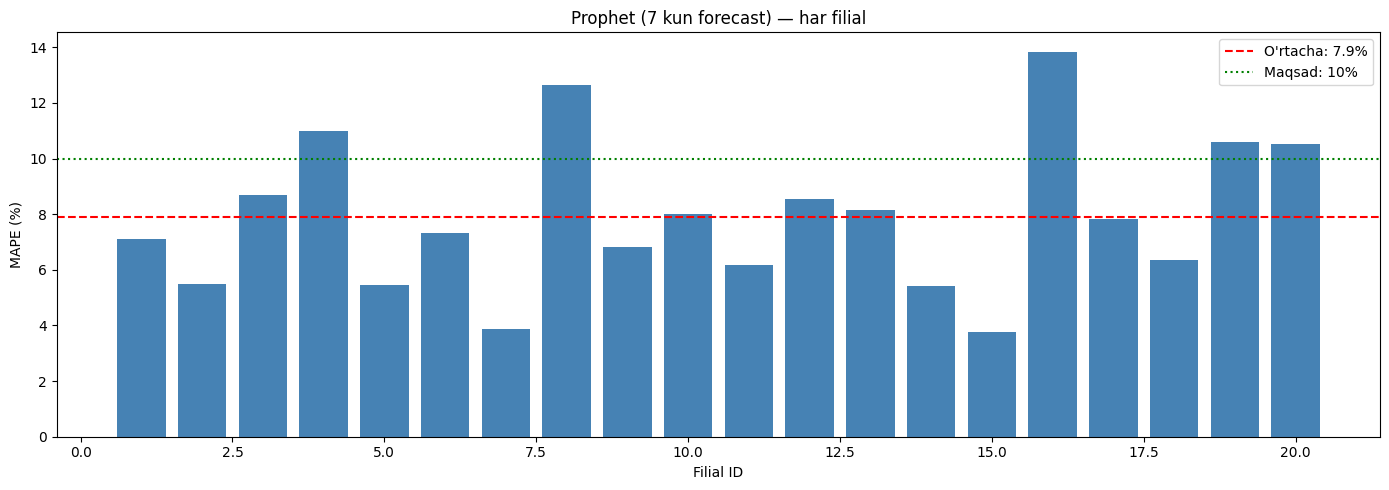

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(metrics_df['branch_id'], metrics_df['mape'], color='steelblue')
ax.axhline(metrics_df['mape'].mean(), color='red', linestyle='--', label=f"O'rtacha: {metrics_df['mape'].mean():.1f}%")
ax.axhline(10, color='green', linestyle=':', label='Maqsad: 10%')
ax.set_xlabel('Filial ID')
ax.set_ylabel('MAPE (%)')
ax.set_title(f'Prophet (7 kun forecast) — har filial')
ax.legend()
plt.tight_layout()
plt.show()

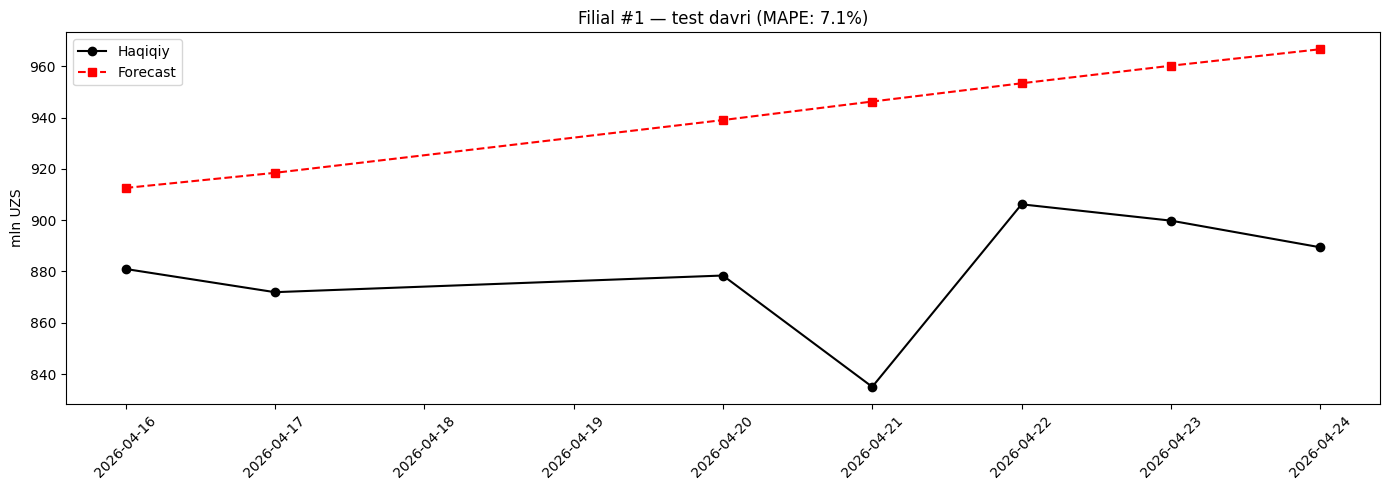

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
p = predictions[1]
ax.plot(p['ds'], p['y'] / 1e6, label='Haqiqiy', marker='o', color='black')
ax.plot(p['ds'], p['yhat'] / 1e6, label='Forecast', marker='s', color='red', linestyle='--')
ax.set_title(f"Filial #1 — test davri (MAPE: {metrics_df.iloc[0]['mape']:.1f}%)")
ax.set_ylabel('mln UZS')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
with open('../models/prophet_models.pkl', 'wb') as f:
    pickle.dump(models, f)
metrics_df.to_csv('../models/prophet_metrics.csv', index=False)
with open('../models/prophet_best_params.pkl', 'wb') as f:
    pickle.dump(best_params, f)
print('Saqlandi')

Saqlandi


In [10]:
# Test davrining tarkibi
bid = 1
p = predictions[bid]
print("Test davri:")
for _, row in p.iterrows():
    d = row['ds']
    print(f"  {d.date()} (hafta kuni: {d.day_name()[:3]}, oy kuni: {d.day:2d}): "
          f"haqiqiy={row['y']/1e6:6.0f}M, forecast={row['yhat']/1e6:6.0f}M, "
          f"xato={(row['yhat']-row['y'])/row['y']*100:+.1f}%")

Test davri:
  2026-04-16 (hafta kuni: Thu, oy kuni: 16): haqiqiy=   881M, forecast=   913M, xato=+3.6%
  2026-04-17 (hafta kuni: Fri, oy kuni: 17): haqiqiy=   872M, forecast=   918M, xato=+5.3%
  2026-04-20 (hafta kuni: Mon, oy kuni: 20): haqiqiy=   878M, forecast=   939M, xato=+6.9%
  2026-04-21 (hafta kuni: Tue, oy kuni: 21): haqiqiy=   835M, forecast=   946M, xato=+13.3%
  2026-04-22 (hafta kuni: Wed, oy kuni: 22): haqiqiy=   906M, forecast=   953M, xato=+5.2%
  2026-04-23 (hafta kuni: Thu, oy kuni: 23): haqiqiy=   900M, forecast=   960M, xato=+6.7%
  2026-04-24 (hafta kuni: Fri, oy kuni: 24): haqiqiy=   889M, forecast=   967M, xato=+8.7%
